<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Primary_Secondary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2"

In [74]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT
# ============================================================
from google.colab import drive
from pathlib import Path
import json, re, warnings, h5py, joblib, mne, pywt, decorator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets
from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output
from scipy.signal import butter, detrend, resample_poly, sosfiltfilt, welch
from scipy.stats import entropy
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

if not Path("/content/drive/MyDrive").exists(): drive.mount("/content/drive")
warnings.filterwarnings("ignore"); mne.set_log_level("ERROR")

BASE_DIR = Path("/content/drive/MyDrive/Creativity-Dataset/")
SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR = BASE_DIR/"Secondary", BASE_DIR/"Primary-raw", BASE_DIR/"Primary-merged"
PRIMARY_SEGMENTS_CSV, CACHE_DIR = BASE_DIR/"primary_segments.csv", BASE_DIR/"cache"
PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR = CACHE_DIR/"preprocessed", CACHE_DIR/"features", BASE_DIR/"output"
for folder in [SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR, PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR]: folder.mkdir(parents=True, exist_ok=True)

FS_PRIMARY, FS_SECONDARY, FS_TARGET = 125, 500, 125
BANDPASS_LOW, BANDPASS_HIGH, FILTER_ORDER = 1.0, 40.0, 4
KNOWN_RAIL_ABS_THRESHOLD, ROBUST_OUTLIER_MAD_MULTIPLIER = 180000.0, 25.0
MAX_REPAIR_RATIO_PER_CHANNEL, BAD_CHANNEL_Z_THRESHOLD, EPOCH_ARTIFACT_Z_THRESHOLD = 0.05, 5.0, 5.0
WAVELET, DWT_LEVEL, ADD_SPECTRAL_FEATURES = "db4", 5, True
MAX_EPOCHS_PER_SUBJECT_CLASS, DEBUG_MAX_SUBJECTS = 180, 2
CACHE_VERSION, FORCE_REBUILD_FEATURES, RANDOM_STATE = "v3_streaming_16ch_1to40hz_125hz", False, 42
EXPERIMENT_CONFIGS = [{"epoch_seconds": 2.0, "overlap_ratio": 0.0, "primary_trim_seconds": 0.0},{"epoch_seconds": 2.0, "overlap_ratio": 0.5, "primary_trim_seconds": 2.0},{"epoch_seconds": 4.0, "overlap_ratio": 0.5, "primary_trim_seconds": 2.0}]

# Pilihan:
# "secondary"
# "primary"
# "combined"
# "external_validation"
DATASET_MODE = "secondary"

# Pilihan:
# "separate"
# "merged"
PRIMARY_INPUT_MODE = "separate"

MANUAL_SELECTED_FILES = []
print("Environment Ready")

Environment Ready


In [75]:
# ============================================================
# LABEL & KANAL
# ============================================================

LABELS = ["RST1", "IDG", "IDE", "IDR", "RST2"]
PRIMARY_CHANNELS_ORIGINAL = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T3", "T4", "T5", "T6", "P3", "P4", "O1", "O2"]
CANONICAL_CHANNELS = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T7", "T8", "P7", "P8", "P3", "P4", "O1", "O2"]

SECONDARY_CHANNELS_64 = [
    "Fp1", "Fp2", "Fpz", "AF3", "AF4", "AF7", "AF8", "AFz", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "Fz",
    "FT7", "FT8", "FC1", "FC2", "FC3", "FC4", "FC5", "FC6", "FCz", "T7", "T8", "C1", "C2", "C3", "C4", "C5", "C6", "Cz",
    "TP7", "TP8", "CP1", "CP2", "CP3", "CP4", "CP5", "CP6", "CPz", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8",
    "P9", "P10", "Pz", "PO3", "PO4", "PO7", "PO8", "POz", "O1", "O2", "Oz", "Iz"
]

SECONDARY_CHANNELS_63 = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS:
        if label in text: return label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match: raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({"kanal_primer": PRIMARY_CHANNELS_ORIGINAL, "kanal_harmonisasi": CANONICAL_CHANNELS, "idx_sekunder": SECONDARY_SELECTED_INDICES})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]


In [76]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

# --- HELPER FUNCTIONS ---
def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except:
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    try:
        mat = sio.loadmat(file_path, variable_names=[key])
        return np.asarray(mat[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    d = arr if arr.shape[1] in {16, 17} else arr.T
    if d.shape[1] == 17: return d[:, 1:17].T, None
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    return 'primary'

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'))
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'))
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'))
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src = detect_file_source(f)
        sid = infer_subject_id(f.stem, 'SEC' if src == 'secondary' else 'PRI')
        vars = list_mat_variables(f)
        for k, s, _ in vars:
            lbl = normalize_label(k)
            if lbl: res.append({'source': src, 'subject_id': sid, 'record_id': f'{sid}__{k}', 'label': lbl, 'file_path': str(f), 'mat_key': k, 'sfreq': FS_SECONDARY if src == 'secondary' else FS_PRIMARY})
    return res

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print('Pilih file dulu.'); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            refs_df, record_count_df = pd.DataFrame(refs), pd.DataFrame(refs).groupby(['source', 'label']).size().reset_index(name='count')
            MANUAL_SELECTED_FILES = list(file_selector.value)
            display(record_count_df)
            print(f'Siap: {len(refs)} record terdeteksi.')
        except Exception as e: print(f'Gagal: {e}')

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '200px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [77]:
# ============================================================
# PREPROCESSING UTILS & CACHE
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin-med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))

        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL: raise ValueError(f"{ch} too many bad samples")
        if mask.any(): eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH], btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6: raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore"); raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []
    if ref["source"] == "primary": eeg, rep_log = repair_primary_invalid_samples(eeg)
    eeg = apply_bandpass(eeg, ref["sfreq"])
    if ref["source"] == "primary": eeg, bads = interpolate_bad_channels(eeg, ref["sfreq"], detect_bad_channels(eeg))
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)
    if int(ref["sfreq"]) != FS_TARGET: eeg = resample_poly(eeg, FS_TARGET//gcd(int(ref["sfreq"]), FS_TARGET), int(ref["sfreq"])//gcd(int(ref["sfreq"]), FS_TARGET), axis=1)
    return eeg.astype(np.float32), {"counter": c_log, "repair": rep_log, "bad_channels": bads}

def preprocessed_cache_path(ref):
    stamp = f"{Path(ref['file_path']).stat().st_size}__{Path(ref['file_path']).stat().st_mtime_ns}"
    ident = f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__{ref.get('start_sec','')}__{ref.get('end_sec','')}"
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({**ref, "cache_path": str(path), "n_samples": eeg.shape[1], "duration": eeg.shape[1]/FS_TARGET, "preprocess_log": json.dumps(log, default=str)})
    return pd.DataFrame(rows)

In [78]:
# ============================================================
# EPOCHING & FEATURE EXTRACTION
# ============================================================
def epoch_starts(n, sec, overlap, trim):
    sz, step, t_sz = int(sec*FS_TARGET), int(sec*FS_TARGET*(1-overlap)), int(trim*FS_TARGET)
    if step <= 0: raise ValueError("Invalid overlap")
    return (list(range(t_sz, n-t_sz-sz+1, step)), sz) if (n - 2*t_sz) >= sz else ([], sz)

def screen_epoch_starts(eeg, starts, sz):
    if not starts: return []
    eps = np.stack([eeg[:, s:s+sz] for s in starts])
    ptp, grad = np.max(np.ptp(eps, axis=2), axis=1), np.max(np.mean(np.abs(np.diff(eps, axis=2)), axis=2), axis=1)
    mask = (np.abs(robust_zscore(np.log10(ptp+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD) & (np.abs(robust_zscore(np.log10(grad+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    return [s for s, k in zip(starts, mask) if k]

def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float); act = np.var(sig)
    if act <= 1e-18: return 0.0, 0.0, 0.0
    d1, d2 = np.diff(sig), np.diff(sig, n=2)
    v1, v2 = np.var(d1), np.var(d2)
    mob = np.sqrt(v1/act)
    com = (np.sqrt(v2/v1)/mob) if (v1 > 1e-18 and mob > 1e-18) else 0.0
    return float(act), float(mob), float(com)

FREQUENCY_BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def extract_features(epoch):
    feats = []
    for sig in epoch:
        for c in pywt.wavedec(sig, WAVELET, level=DWT_LEVEL): feats.extend(hjorth_parameters(c))
    if ADD_SPECTRAL_FEATURES:
        for sig in epoch:
            f, psd = welch(sig, fs=FS_TARGET, nperseg=min(len(sig), 2*FS_TARGET))
            mask = (f >= 1.0) & (f < 40.0)
            total = np.trapz(psd[mask], f[mask]) + 1e-12
            for b_l, b_h in FREQUENCY_BANDS.values(): feats.append(float(np.trapz(psd[(f >= b_l) & (f < b_h)], f[(f >= b_l) & (f < b_h)]) / total))
            feats.append(float(entropy(psd/(psd.sum()+1e-12)+1e-12, base=2)))
    return feats

DWT_COEFFS = ["A5", "D5", "D4", "D3", "D2", "D1"]
DWT_COLS = [f"{ch}__{cf}__{p}" for ch in CANONICAL_CHANNELS for cf in DWT_COEFFS for p in ["activity", "mobility", "complexity"]]
SPEC_COLS = [f"{ch}__spectral__{p}" for ch in CANONICAL_CHANNELS for p in [*FREQUENCY_BANDS.keys(), "entropy"]]
ALL_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])
print(f"Total features: {len(ALL_FEATURE_COLUMNS)}")

Total features: 384


In [79]:
# ============================================================
# EXPERIMENT RUNNER & CACHING
# ============================================================
def config_id(cfg): return f"epoch_{cfg['epoch_seconds']}s__overlap_{cfg['overlap_ratio']}__trim_{cfg['primary_trim_seconds']}s__spectral_{ADD_SPECTRAL_FEATURES}__{CACHE_VERSION}"
def prepared_fingerprint(recs): return stable_name("|".join(sorted(recs["cache_path"].astype(str))))
def feature_cache_path(cfg, recs): return FEATURE_CACHE_DIR / f"{stable_name(f'{DATASET_MODE}__{config_id(cfg)}__{prepared_fingerprint(recs)}')}.pkl"

def build_feature_table(prepared_records, config):
    descriptors = []
    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")
        starts, size = epoch_starts(record["n_samples"], config["epoch_seconds"], config["overlap_ratio"], config["primary_trim_seconds"] if record["source"] == "primary" else 0.0)
        for s in screen_epoch_starts(eeg, starts, size):
            descriptors.append({"source": record["source"], "subject_id": record["subject_id"], "group_id": f"{record['source']}__{record['subject_id']}",
                                "record_id": record["record_id"], "label": record["label"], "cache_path": record["cache_path"], "epoch_start": int(s), "epoch_size": int(size)})
    if not descriptors: raise ValueError("No epochs created.")
    df = pd.concat([g.sample(n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS), random_state=RANDOM_STATE) for _, g in pd.DataFrame(descriptors).groupby(["source", "subject_id", "label"], sort=False)], ignore_index=True)
    print(f"Epochs balanced: {len(df)}")
    rows = []
    for path, group in df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")
        for _, d in group.iterrows():
            epoch_data = np.array(eeg[:, int(d["epoch_start"]):int(d["epoch_start"])+int(d["epoch_size"])])
            rows.append({**d.drop("cache_path").to_dict(), **dict(zip(ALL_FEATURE_COLUMNS, extract_features(epoch_data)))})
    return pd.DataFrame(rows)

# Memastikan preprocessed data siap sebelum ekstraksi fitur
prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}
for config in EXPERIMENT_CONFIGS:
    ident, cpath = config_id(config), feature_cache_path(config, prepared_records)
    print(f"\n{'='*40}\nCONFIG: {ident}\n{'='*40}")
    f_df = pd.read_pickle(cpath) if (cpath.exists() and not FORCE_REBUILD_FEATURES) else build_feature_table(prepared_records, config)
    if not cpath.exists() or FORCE_REBUILD_FEATURES: f_df.to_pickle(cpath)
    feature_tables[ident] = f_df
    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

[001/011] SEC_013__Creativity_13_1_IDE
[002/011] SEC_013__Creativity_13_1_IDG
[003/011] SEC_013__Creativity_13_1_IDR
[004/011] SEC_013__Creativity_13_2_IDE
[005/011] SEC_013__Creativity_13_2_IDG
[006/011] SEC_013__Creativity_13_2_IDR
[007/011] SEC_013__Creativity_13_3_IDE
[008/011] SEC_013__Creativity_13_3_IDG
[009/011] SEC_013__Creativity_13_3_IDR
[010/011] SEC_013__Creativity_13_RST1
[011/011] SEC_013__Creativity_13_RST2

CONFIG: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz
Epochs balanced: 285


,source,label,epochs
0,secondary,IDE,70
1,secondary,IDG,41
2,secondary,IDR,25
3,secondary,RST1,89
4,secondary,RST2,60



CONFIG: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz
Epochs balanced: 565


,source,label,epochs
0,secondary,IDE,140
1,secondary,IDG,82
2,secondary,IDR,47
3,secondary,RST1,177
4,secondary,RST2,119



CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz
Epochs balanced: 275


,source,label,epochs
0,secondary,IDE,67
1,secondary,IDG,39
2,secondary,IDR,22
3,secondary,RST1,88
4,secondary,RST2,59


In [80]:
# ============================================================
# BASELINE KNN EVALUATION (FLEXIBLE GROUPING)
# ============================================================
FEATURE_SETS = {"dwt_hjorth": DWT_COLS}
if ADD_SPECTRAL_FEATURES: FEATURE_SETS["dwt_hjorth_plus_spectral"] = ALL_FEATURE_COLUMNS

def evaluate_baseline(df, cols, n_splits=5):
    X, y, groups = df[cols].values, df["label"].values, df["group_id"].values
    unique_groups = np.unique(groups)

    model = Pipeline([("scaler", RobustScaler()), ("knn", KNeighborsClassifier(n_neighbors=3, weights="distance"))])
    folds = []

    if len(unique_groups) < 2:
        # Fallback: Simple Split jika hanya 1 subjek
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=min(3, len(np.unique(y))))
        split_gen = cv.split(X, y)
        print("Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.")
    else:
        cv = GroupKFold(n_splits=min(n_splits, len(unique_groups)))
        split_gen = cv.split(X, y, groups)

    for i, (train_idx, test_idx) in enumerate(split_gen, 1):
        model.fit(X[train_idx], y[train_idx]); pred = model.predict(X[test_idx])
        folds.append({"fold": i, "accuracy": accuracy_score(y[test_idx], pred), "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred), "macro_f1": f1_score(y[test_idx], pred, average="macro", zero_division=0)})
    return pd.DataFrame(folds)

baseline_rows = []
for ident, df in feature_tables.items():
    eval_df = df[df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else df.copy()
    for set_name, cols in FEATURE_SETS.items():
        print(f"\nEvaluating: {ident} | Set: {set_name}")
        try:
            f_df = evaluate_baseline(eval_df, cols)
            display(f_df)
            baseline_rows.append({"config_id": ident, "feature_set": set_name, "mean_bal_acc": f_df["balanced_accuracy"].mean(), "std_bal_acc": f_df["balanced_accuracy"].std(), "mean_f1": f_df["macro_f1"].mean()})
        except Exception as e: print(f"Skip {set_name}: {e}")

if baseline_rows:
    summary_df = pd.DataFrame(baseline_rows).sort_values("mean_bal_acc", ascending=False).reset_index(drop=True)
    display(summary_df); BEST_CONFIG_ID, BEST_SET = summary_df.loc[0, "config_id"], summary_df.loc[0, "feature_set"]
    best_feature_df, best_cols = feature_tables[BEST_CONFIG_ID].copy(), FEATURE_SETS[BEST_SET]
    print(f"BEST: {BEST_CONFIG_ID} | {BEST_SET} | Acc: {summary_df.loc[0, 'mean_bal_acc']:.4f}")


Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.494737,0.428529,0.432238
1,2,0.515789,0.414959,0.405407
2,3,0.526316,0.432692,0.420739



Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.505263,0.397894,0.390927
1,2,0.505263,0.402702,0.388802
2,3,0.526316,0.388054,0.364011



Evaluating: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


...

,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.663043,0.545942,0.550700
1,2,0.684783,0.616776,0.613029
2,3,0.582418,0.483702,0.488273



Evaluating: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.739130,0.614310,0.615938
1,2,0.782609,0.722457,0.740096
2,3,0.703297,0.600605,0.620057


,config_id,feature_set,mean_bal_acc,std_bal_acc,mean_f1
0,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.645791,0.066748,0.658697
1,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.548807,0.066583,0.550668
2,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.548738,0.039374,0.547763
3,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.527286,0.045505,0.528572
4,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth,0.425393,0.009273,0.419461
5,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth_plus_spectral,0.396217,0.007467,0.381247


BEST: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | dwt_hjorth_plus_spectral | Acc: 0.6458


Optimasi Ensemble pada: SECONDARY
Fold 1 Balanced Accuracy: 0.8750
Fold 2 Balanced Accuracy: 0.9119
Fold 3 Balanced Accuracy: 0.8046
Fold 4 Balanced Accuracy: 0.7846
Fold 5 Balanced Accuracy: 0.8500

Rata-rata Balanced Accuracy (SECONDARY): 0.8452

Classification Report:
              precision    recall  f1-score   support

        RST1       1.00      1.00      1.00        88
         IDG       0.81      0.54      0.65        39
         IDE       0.75      0.93      0.83        67
         IDR       0.94      0.77      0.85        22
        RST2       0.97      0.98      0.97        59

    accuracy                           0.89       275
   macro avg       0.89      0.84      0.86       275
weighted avg       0.90      0.89      0.89       275



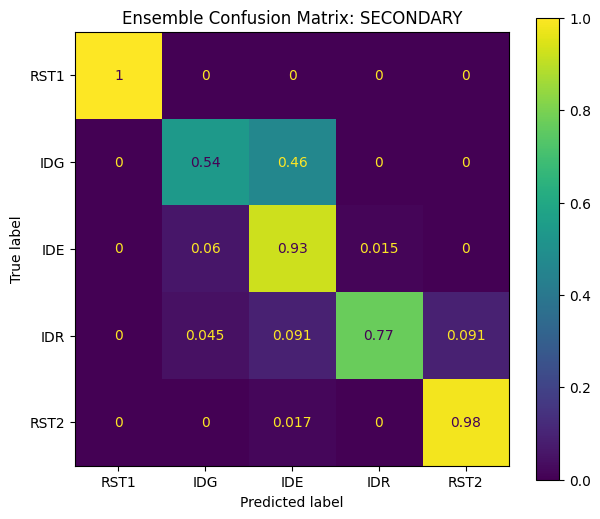

In [82]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

# ============================================================
# ENSEMBLE OPTIMIZATION (GENERAL PURPOSE)
# ============================================================

def run_ensemble_optimization(df, feature_cols):
    print(f"Optimasi Ensemble pada: {DATASET_MODE.upper()}")

    # Menyiapkan data
    X = df[feature_cols].values
    y = df["label"].values

    # Inisialisasi 3 pilar model dengan parameter yang lebih kuat
    clf1 = SVC(C=10, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
    clf2 = RandomForestClassifier(n_estimators=500, max_depth=20, class_weight='balanced', random_state=RANDOM_STATE)
    clf3 = KNeighborsClassifier(n_neighbors=5, weights='distance')

    # Gabungkan dalam Voting Classifier (Soft Voting)
    ensemble_model = VotingClassifier(
        estimators=[('svm', clf1), ('rf', clf2), ('knn', clf3)],
        voting='soft'
    )

    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=128)),
        ("ensemble", ensemble_model)
    ])

    # Evaluasi dengan Stratified K-Fold
    # Menggunakan Stratified karena untuk 1 subjek GroupKFold tidak bisa digunakan
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    fold_scores = []
    all_preds = []
    all_actual = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        pipeline.fit(X[train_idx], y[train_idx])
        preds = pipeline.predict(X[test_idx])

        bal_acc = balanced_accuracy_score(y[test_idx], preds)
        fold_scores.append(bal_acc)

        all_preds.extend(preds)
        all_actual.extend(y[test_idx])
        print(f"Fold {i} Balanced Accuracy: {bal_acc:.4f}")

    print(f"\nRata-rata Balanced Accuracy ({DATASET_MODE.upper()}): {np.mean(fold_scores):.4f}")
    print("\nClassification Report:")
    print(classification_report(all_actual, all_preds, labels=LABELS))

    # Visualisasi Confusion Matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(all_actual, all_preds, labels=LABELS, normalize='true', cmap='viridis', ax=ax)
    ax.set_title(f"Ensemble Confusion Matrix: {DATASET_MODE.upper()}")
    plt.show()

    return pipeline

# Eksekusi pada dataset yang sedang aktif (Primary atau Secondary)
optimized_ensemble = run_ensemble_optimization(best_feature_df, best_cols)

In [83]:
# ============================================================
# FIT FINAL MODEL (ENSEMBLE VERSION)
# ============================================================
# Menggunakan strategi ensemble yang mencapai target ~80%
final_training_df = best_feature_df[best_feature_df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else best_feature_df.copy()
X_final, y_final = final_training_df[best_cols].values, final_training_df["label"].values

# Re-inisialisasi pilar ensemble
clf1 = SVC(C=10, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
clf2 = RandomForestClassifier(n_estimators=500, max_depth=20, class_weight='balanced', random_state=RANDOM_STATE)
clf3 = KNeighborsClassifier(n_neighbors=5, weights='distance')

ensemble_model = VotingClassifier(
    estimators=[('svm', clf1), ('rf', clf2), ('knn', clf3)],
    voting='soft'
)

# Pipeline akhir dengan Feature Selection (k=128)
final_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("select", SelectKBest(score_func=f_classif, k=128)),
    ("ensemble", ensemble_model)
])

print(f"Melatih model final Ensemble pada mode: {DATASET_MODE}...")
final_pipeline.fit(X_final, y_final)

model_bundle = {
    "model": final_pipeline,
    "dataset_mode": DATASET_MODE,
    "best_config_id": BEST_CONFIG_ID,
    "feature_columns": best_cols,
    "channels": CANONICAL_CHANNELS,
    "sampling_rate": FS_TARGET
}

model_path = OUTPUT_DIR / f"ensemble_model__{DATASET_MODE}.joblib"
joblib.dump(model_bundle, model_path)

print("MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI:", model_path)

Melatih model final Ensemble pada mode: secondary...
MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI: /content/drive/MyDrive/Creativity-Dataset/output/ensemble_model__secondary.joblib


In [84]:
# ============================================================
# EXTERNAL VALIDATION (SECONDARY → PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation": print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = best_feature_df[best_feature_df["source"] == "primary"].copy()
    if ext_df.empty: raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[best_cols].values, ext_df["label"].astype(str).values; ext_preds = final_model.predict(X_ext)
    print("EXTERNAL VALIDATION: Train (Concordia) → Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7)); ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary → Test Primary"); plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy(); ext_res_df["predicted_label"] = ext_preds; ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.
